# 03 — Reproduce the main BBBC021 figures

This notebook replays the manuscript BBBC021 panels from **cached metrics** shipped in `source/cached_results/` (small JSON/CSV, no 400 MB evaluation tables).

1. Minimum non-redundant feature count (CellProfiler 1,284 / DeepProfiler 440 / MorphAgent 291).
2. Four-task benchmark: perturbation detection, MoA prediction, same-MoA matching, L1000 regression. Bars: CellProfiler, pretrained DeepProfiler, DeepProfiler retrained on BBBC021, MorphAgent. Significance marks follow the manuscript; `ns` is omitted.

Optional full recompute needs large evaluation CSVs under `data/evaluation/` (not on GitHub). Leave `RECOMPUTE = False`.


In [1]:
from pathlib import Path
import sys

HERE = Path.cwd().resolve()
if HERE.name == "notebook":
    TUTORIAL = HERE.parent
elif (HERE / "code").is_dir() and (HERE / "source").is_dir():
    TUTORIAL = HERE
else:
    TUTORIAL = HERE
sys.path.insert(0, str(TUTORIAL / "code"))

import importlib
import paths as P
P = importlib.reload(P)
print("Tutorial root:", P.ROOT)
print("data/        :", P.DATA_DIR)
print("source/      :", P.SOURCE_DIR)
print("code/        :", P.CODE_DIR)

import pandas as pd
from IPython.display import Image, display
import reproduce_main_figures as bb
bb = importlib.reload(bb)

RECOMPUTE = False
bb.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Cached results:", P.CACHED_RESULTS)
print("Eval tables   :", bb.evaluation_tables_available())
print("Output dir    :", bb.OUTPUT_DIR)


Tutorial root: /Users/yez/Desktop/tutorial_BBBC021
data/        : /Users/yez/Desktop/tutorial_BBBC021/data
source/      : /Users/yez/Desktop/tutorial_BBBC021/source
code/        : /Users/yez/Desktop/tutorial_BBBC021/code
Cached results: /Users/yez/Desktop/tutorial_BBBC021/source/cached_results
Eval tables   : False
Output dir    : /Users/yez/Desktop/tutorial_BBBC021/data/outputs


## 1. MorphAgent 467-name vocabulary


In [2]:
names_467 = bb.load_morphagent_467_names()
print(f"{len(names_467)} named features")
for i, n in enumerate(names_467[:15], 1):
    print(f"  {i:3d}. {n}")
print("...")
print("vlm_ features:", sum(n.startswith("vlm_") for n in names_467))


467 named features
    1. tubulin_intensity_total
    2. actin_fiber_alignment_index
    3. cell_roundness_mean
    4. dapi_texture_entropy
    5. tubulin_actin_overlap_fraction
    6. cell_confluence_ratio
    7. dapi_intensity_std
    8. actin_radial_distribution
    9. tubulin_texture_contrast
   10. cytoplasm_nucleus_area_ratio
   11. nucleus_area_mean
   12. dapi_texture_haralick_contrast_mean
   13. micronuclei_count_mean
   14. tubulin_intensity_skewness_mean
   15. tubulin_fiber_alignment_index
...
vlm_ features: 28


## 2. Non-redundant feature count

A feature is redundant if Pearson $|r| > 0.9$ with an earlier column (greedy filter). Manuscript lock-in: **1,284 / 440 / 291**.


,n_total,n_var,n_const_dropped,n_redundant_dropped,n_min_subset,n_rows
CellProfiler,6278,6256,22,4972,1284,3652
DeepProfiler,672,672,0,232,440,3552
MorphAgent,467,467,0,176,291,3552


Saved /Users/yez/Desktop/tutorial_BBBC021/data/outputs/min_nonredundant_subset.png/.svg/.pdf


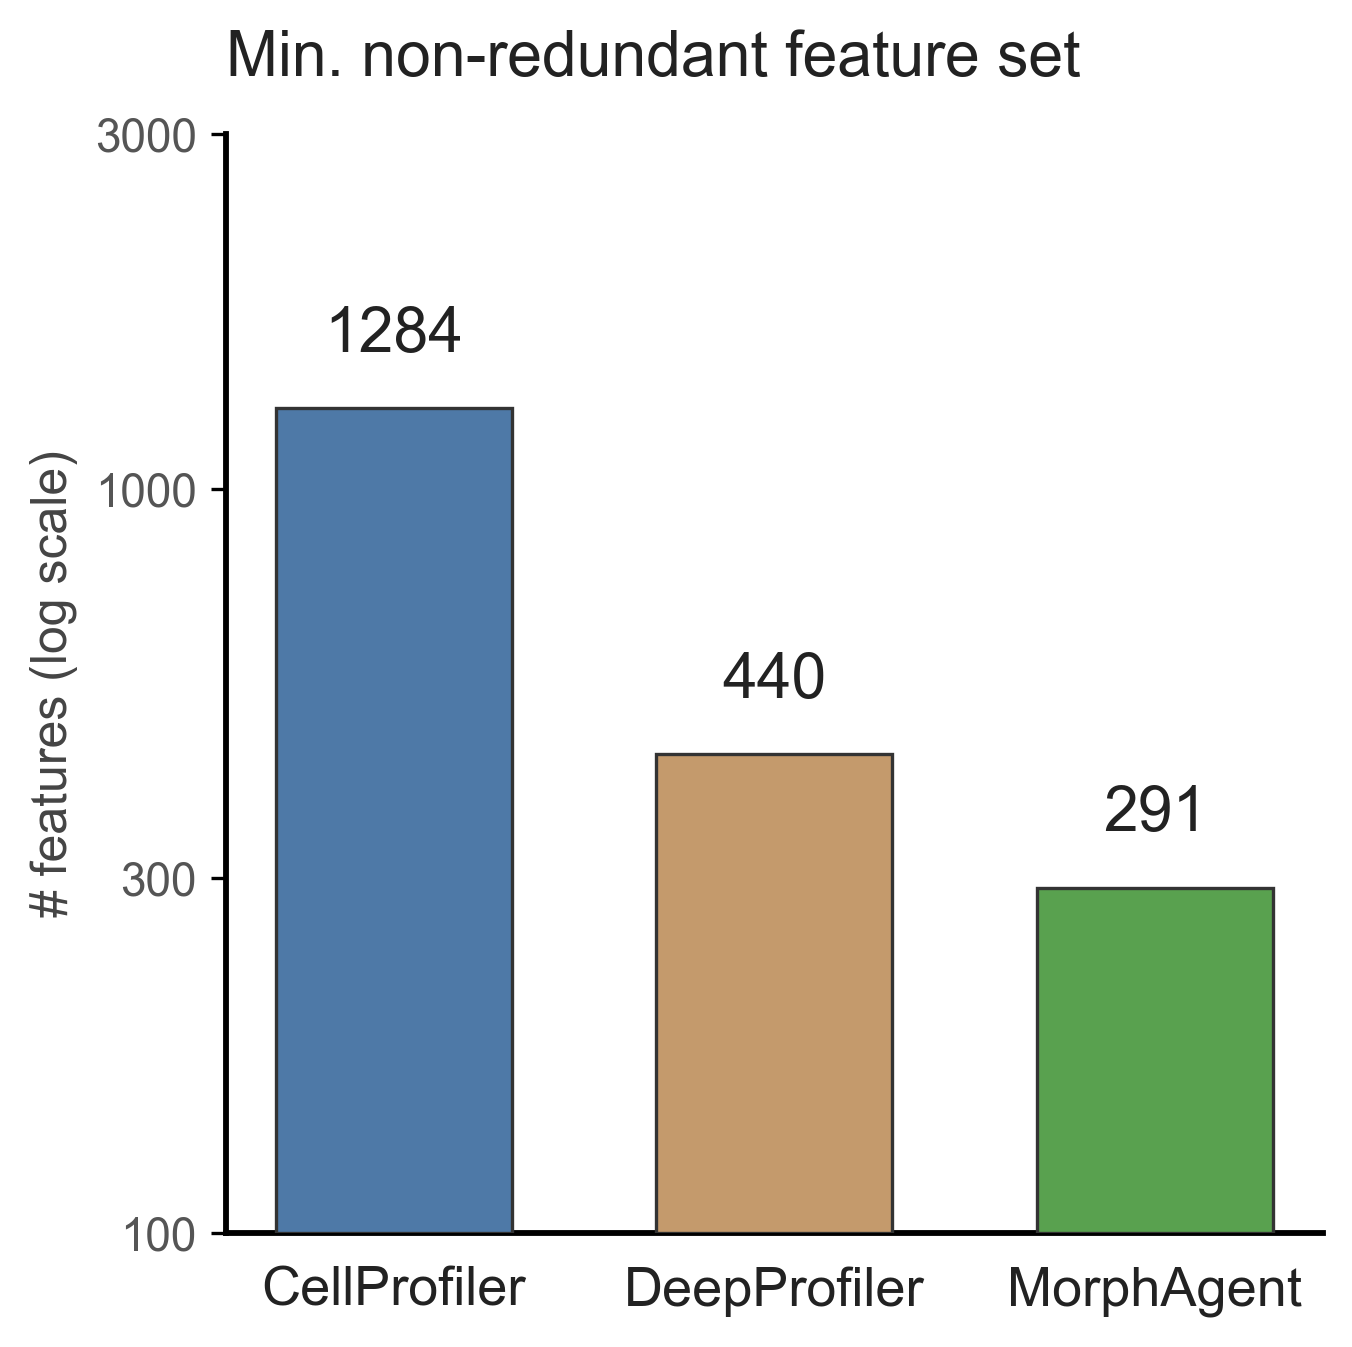

  CellProfiler   reproduced=1284  manuscript=1284
  DeepProfiler   reproduced= 440  manuscript= 440
  MorphAgent     reproduced= 291  manuscript= 291


In [3]:
if RECOMPUTE and bb.evaluation_tables_available():
    counts = bb.compute_nonredundant_counts(recompute=True)
else:
    counts = bb.load_cached_nonredundant()
display(counts)
png = bb.plot_nonredundant(counts, out_stem=bb.OUTPUT_DIR / "min_nonredundant_subset")
display(Image(filename=str(png)))
for method, target in bb.PAPER_NONREDUNDANT.items():
    got = int(counts.loc[method, "n_min_subset"])
    print(f"  {method:13s}  reproduced={got:4d}  manuscript={target:4d}")


## 3. Four-task benchmark

Shared protocol: numeric columns, impute non-finite values, z-score. Uncertainty is a 95% bootstrap CI (2,000 resamples). The figure copies the manuscript brackets and hides non-significant comparisons.

L1000 $R^2$ uses the released random-split MLP run (not retrained here).


In [4]:
if RECOMPUTE and bb.evaluation_tables_available():
    datasets = bb.load_benchmark_tables(morphagent_source="paper_eval")
    results = bb.run_four_benchmarks(datasets, recompute=True, cache_tag="paper_eval")
else:
    results = bb.load_cached_four_benchmarks()

for task_key, title in [
    ("perturbation_detection", "Perturbation detection"),
    ("moa_detection", "MoA prediction"),
    ("same_moa_matching", "Same-MoA matching"),
    ("l1000_regression", "L1000 regression"),
]:
    task = results[task_key]
    print(f"\n{title}")
    for m in bb.METHODS_ORDER:
        r = task["methods"][m]
        print(
            f"  {bb.method_label(m):40s}  "
            f"{r['metric_name']}={r['metric']:.4f}  "
            f"CI95=[{r['ci95'][0]:.4f}, {r['ci95'][1]:.4f}]"
        )


Loading cached benchmark results: /Users/yez/Desktop/tutorial_BBBC021/source/cached_results/four_benchmark_results_paper_eval_4method.json

Perturbation detection
  CellProfiler                              mAP=0.1544  CI95=[0.1497, 0.1593]
  DeepProfiler                              mAP=0.1902  CI95=[0.1853, 0.1951]
  DeepProfiler (retrained on BBBC021)       mAP=0.0423  CI95=[0.0416, 0.0429]
  MorphAgent                                mAP=0.2282  CI95=[0.2218, 0.2342]

MoA prediction
  CellProfiler                              Accuracy=0.4719  CI95=[0.4185, 0.5281]
  DeepProfiler                              Accuracy=0.5787  CI95=[0.5281, 0.6292]
  DeepProfiler (retrained on BBBC021)       Accuracy=0.1657  CI95=[0.1292, 0.2051]
  MorphAgent                                Accuracy=0.6208  CI95=[0.5702, 0.6713]

Same-MoA matching
  CellProfiler                              mAP=0.5244  CI95=[0.4564, 0.5971]
  DeepProfiler                              mAP=0.5428  CI95=[0.4728, 0.6150]
  

## 4. Four-panel figure


Saved /Users/yez/Desktop/tutorial_BBBC021/data/outputs/four_benchmarks.png/.svg/.pdf


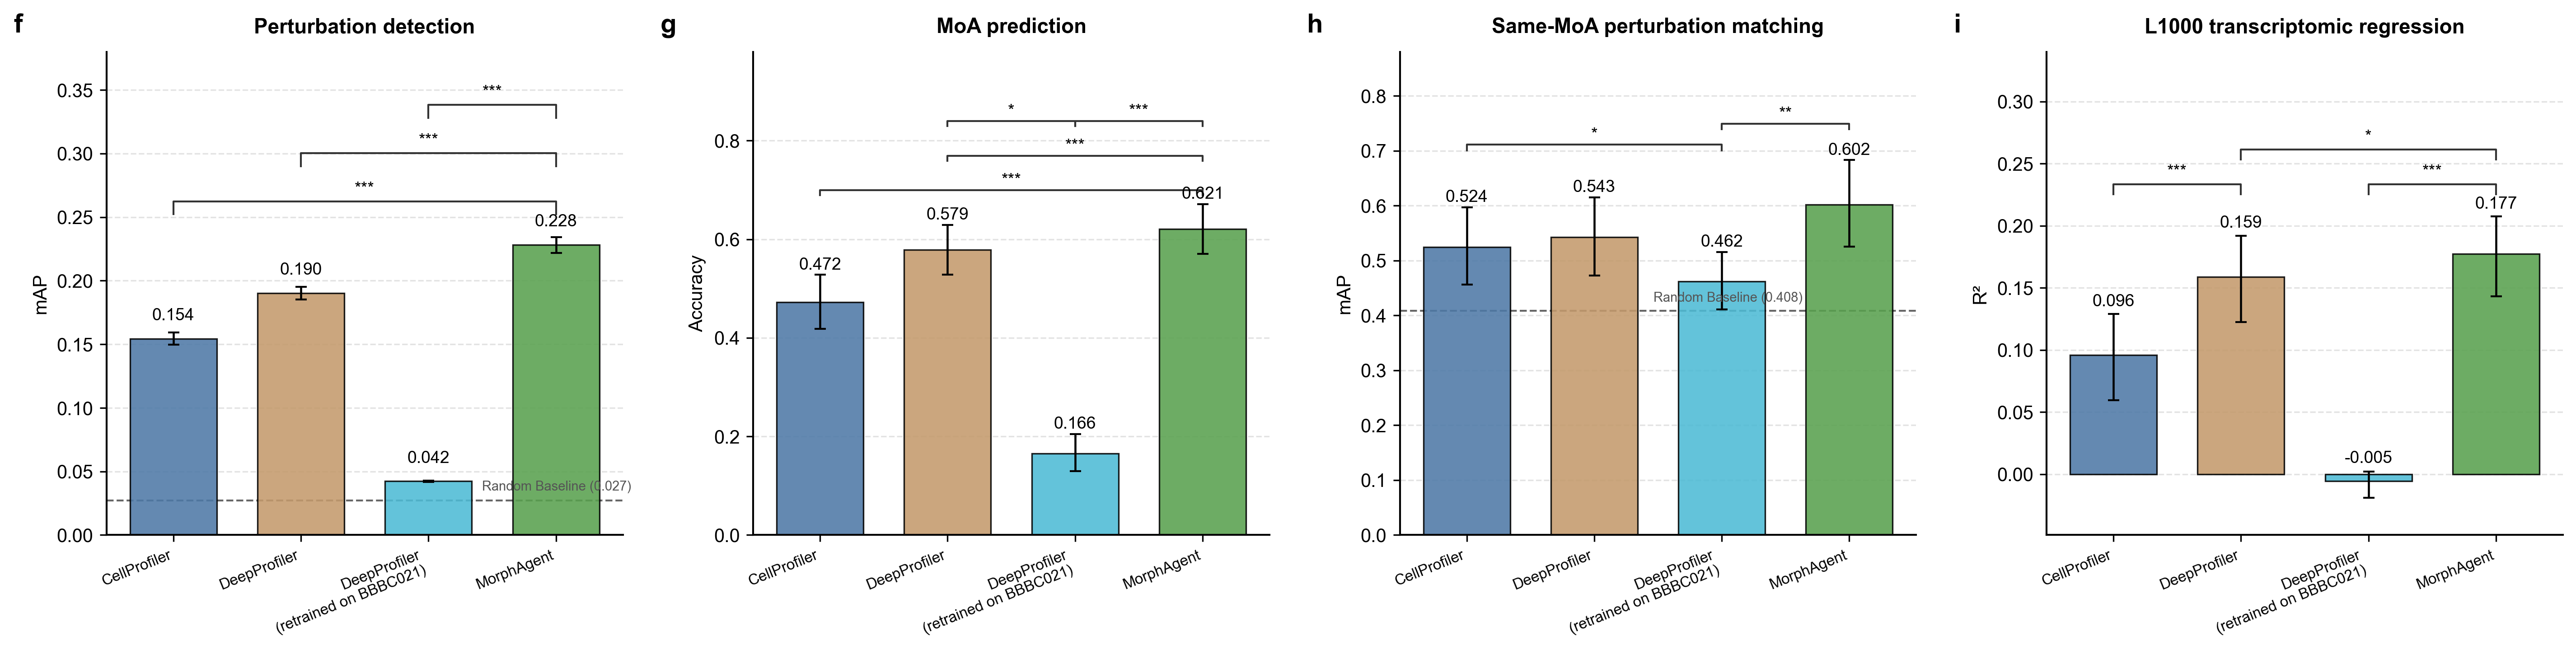

,task,method,reproduced,manuscript,abs_diff,match_3dp
0,perturbation_detection,CellProfiler,0.1544,0.154,0.000376,True
1,perturbation_detection,DeepProfiler,0.1902,0.190,0.000178,True
2,perturbation_detection,DeepProfiler (retrained on BBBC021),0.0423,0.042,0.000286,True
3,perturbation_detection,MorphAgent,0.2282,0.228,0.000160,True
4,moa_detection,CellProfiler,0.4719,0.472,0.000090,True
5,moa_detection,DeepProfiler,0.5787,0.579,0.000348,True
6,moa_detection,DeepProfiler (retrained on BBBC021),0.1657,0.166,0.000270,True
7,moa_detection,MorphAgent,0.6208,0.621,0.000213,True
8,same_moa_matching,CellProfiler,0.5244,0.524,0.000411,True
9,same_moa_matching,DeepProfiler,0.5428,0.543,0.000167,True


In [5]:
png = bb.plot_four_benchmarks(results, out_stem=bb.OUTPUT_DIR / "four_benchmarks")
display(Image(filename=str(png)))
cmp_df = bb.compare_to_paper(results)
display(cmp_df)


## 5. Supplementary: shared ANOVA ranking on perturbation detection


method,CellProfiler,DeepProfiler,MorphAgent
k,,,
100,0.178177,0.181407,0.214794
1600,0.181875,NaN,NaN
200,0.198011,0.189749,0.226113
400,0.206264,0.194157,0.201133
50,0.127902,0.169958,0.193176
800,0.200471,NaN,NaN
All,0.154376,0.190178,0.191814


Saved /Users/yez/Desktop/tutorial_BBBC021/data/outputs/si_anova_perturbation_detection.png/.svg/.pdf


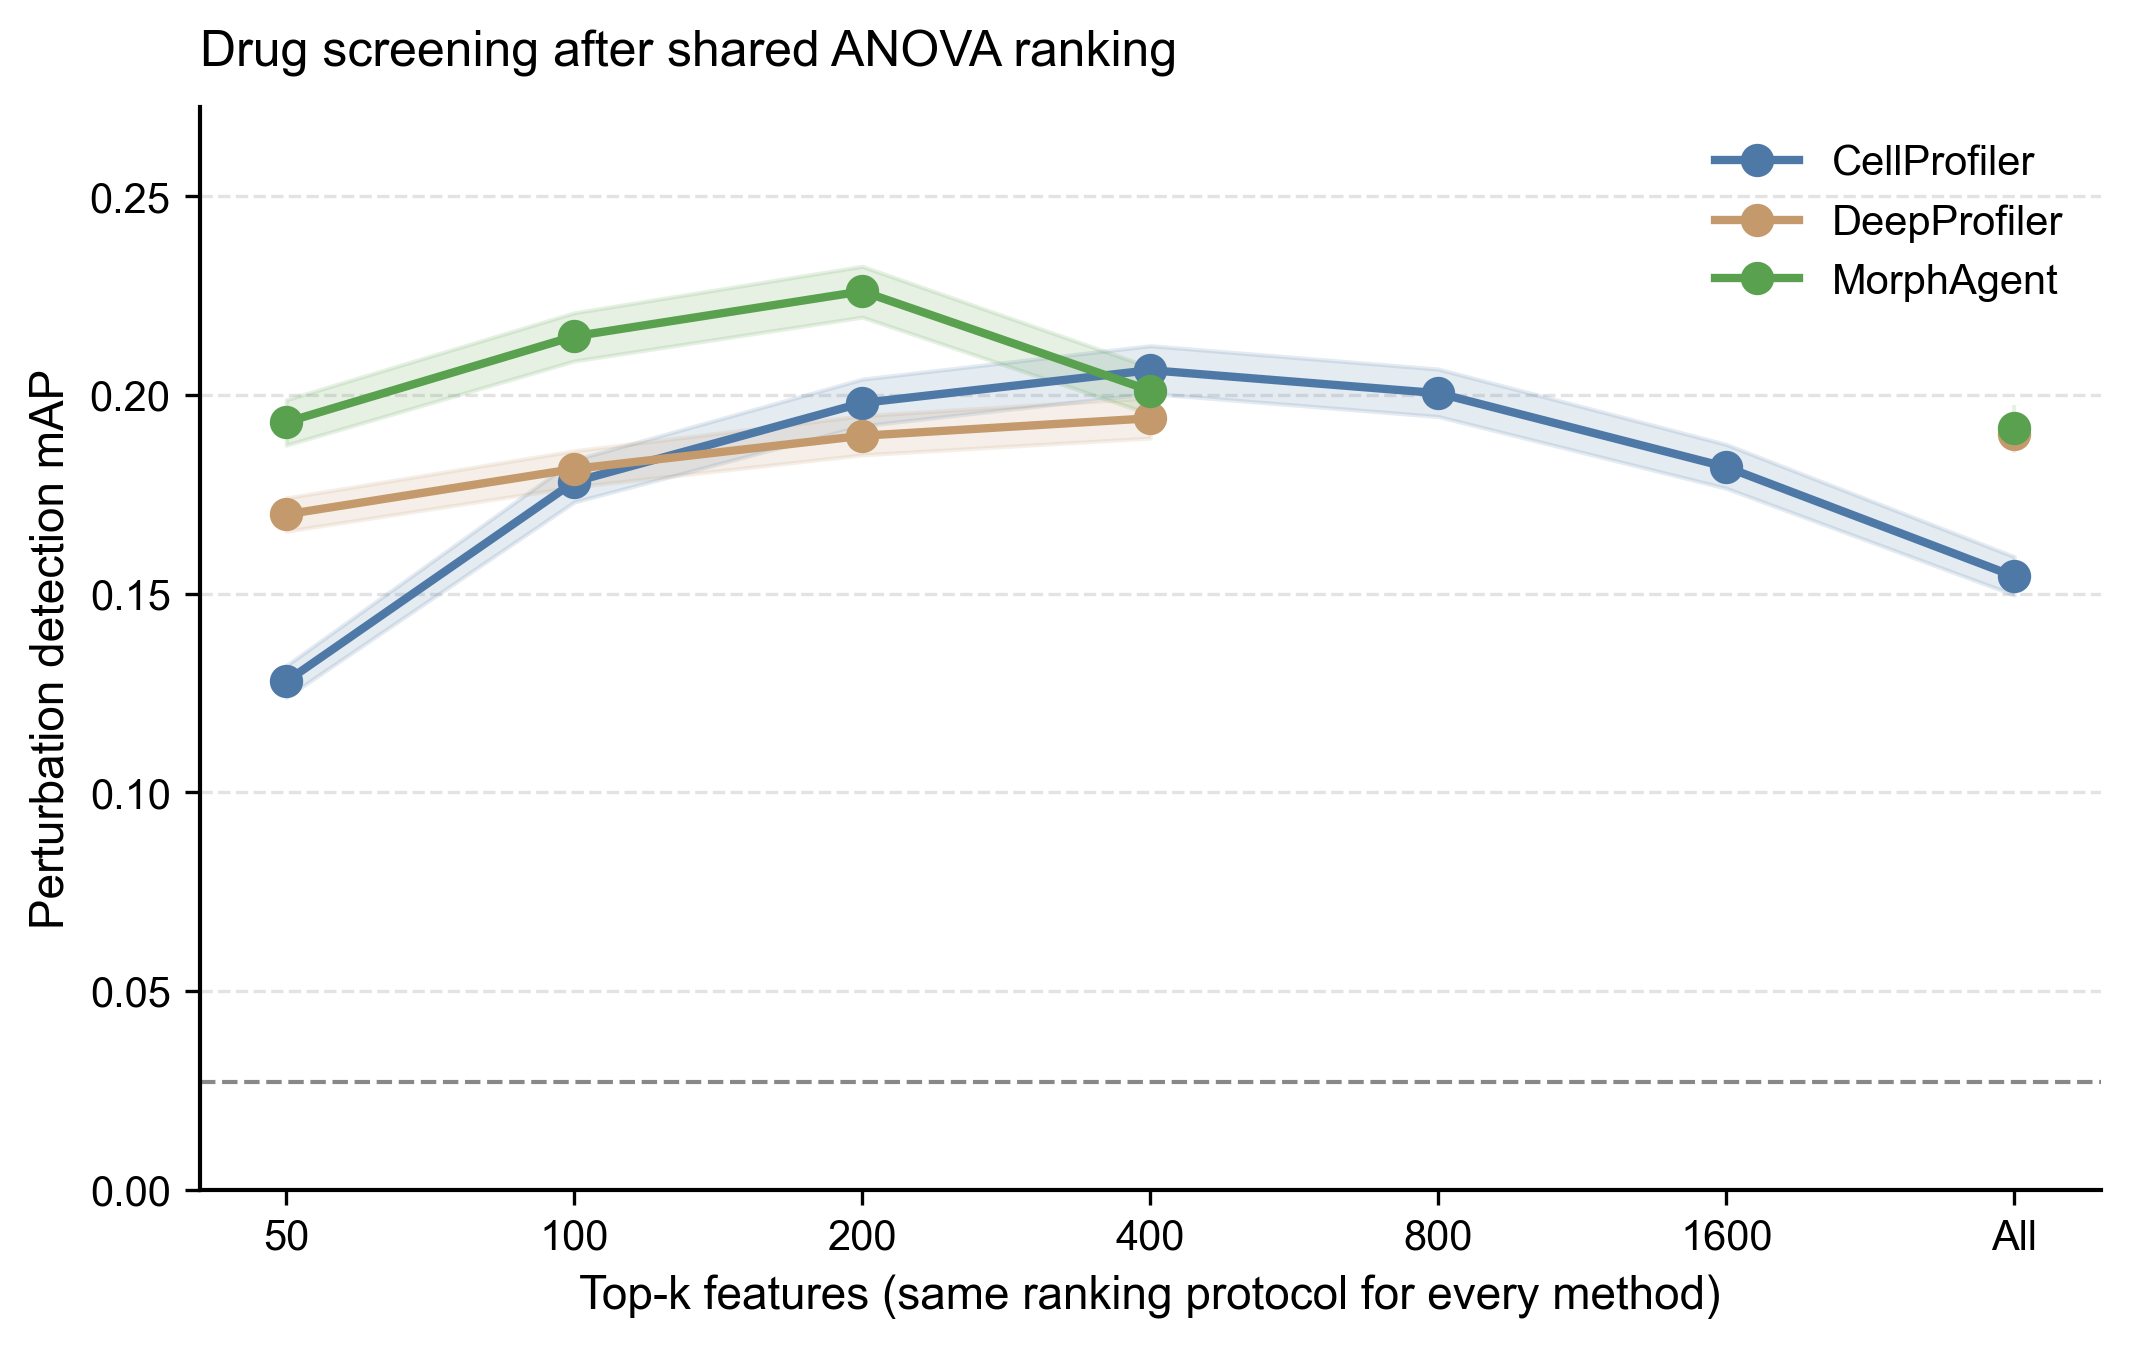

In [6]:
if RECOMPUTE and bb.evaluation_tables_available():
    datasets_named = bb.load_benchmark_tables(morphagent_source="467")
    si = bb.run_si_anova_perturbation_detection(datasets_named, recompute=True)
else:
    si = bb.load_cached_si_anova()
display(si.pivot(index="k", columns="method", values="mAP"))
png = bb.plot_si_anova_perturbation(si, out_stem=bb.OUTPUT_DIR / "si_anova_perturbation_detection")
display(Image(filename=str(png)))


## 6. Files

- `source/cached_results/` — metrics + figures shipped with the tutorial
- `data/outputs/` — plots written by this notebook
- `source/feature_library/` — the 467 extractors used in notebook 02
